* used mainly for saving memory (lazy evaluation)

<br><br>

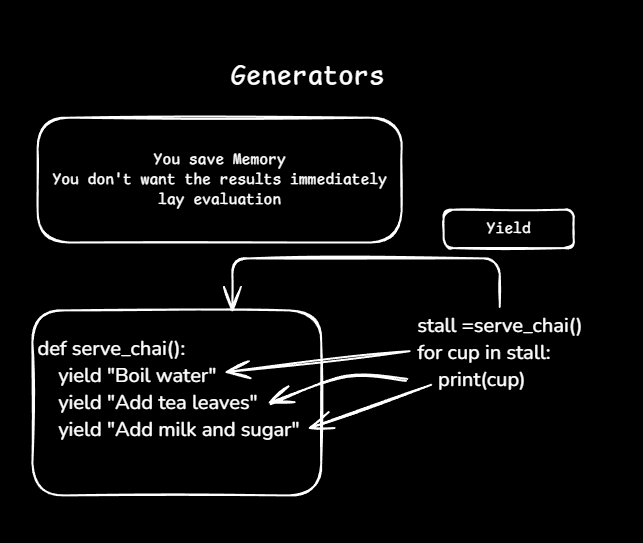

In [9]:
def serve_chai():
    yield "Boil water"
    yield "Add tea leaves"
    yield "Add milk and sugar"

stall=serve_chai()
print(stall) #<generator object >
for cup in stall:
    print(cup)


def get_chai_list():
    return ['cup1', 'cup2', 'cup3']

# generator function
def get_chai_get():
    yield 'cup1'
    yield 'cup2'
    yield 'cup3'

chai_list=get_chai_list()
chai_get=get_chai_get() 
print(chai_list)  #['cup1', 'cup2', 'cup3']
print(next(chai_get))
print(next(chai_get))
print(next(chai_get))
#print(next(chai_get))  # gives StopIteration error

# print(next(chai_get)) #StopIteration

<generator object serve_chai at 0x00000264A7C1D640>
Boil water
Add tea leaves
Add milk and sugar
['cup1', 'cup2', 'cup3']
cup1
cup2
cup3


## Infinite Generators 


In [14]:
def infinte_chai():
    count=1
    while True:
        yield f'Refill #{count}'
        count+=1

refill=infinte_chai()
user2=infinte_chai()

for _ in range(5):
    print(next(refill))

for _ in range (6):
    print(next(user2))

Refill #1
Refill #2
Refill #3
Refill #4
Refill #5
Refill #7
Refill #8
Refill #9
Refill #10
Refill #11
Refill #12


## Sending value to a generator 
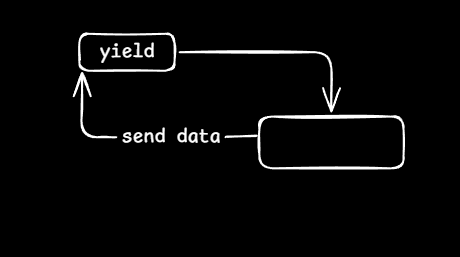

In [ ]:
def chai_customer():
    print('Welcome ! what would you like to have ?')
    order=yield
    while True:
        print(f'Preparing :{order}')
        order=yield

stall=chai_customer()
next(stall)  #start the generator

stall.send('Masala Chai')
stall.send('Ginger Chai')

Welcome ! what would you like to have ?


## Yield form and close the generators

In [9]:
def local_chai():
    yield "Masala Chai"
    yield "Ginger Chai"

def imported_chai():
    yield "Matcha"
    yield "oolong"

def full_menu():
    yield from local_chai()
    yield from imported_chai()

for chai in full_menu():
    print(chai)

def chaI_stall():
    try:
        while True:
            order=yield "Waiting for the order"
    except:
        print("Stalll closed ,No more chau")

stall=chaI_stall()
print(next(stall))
stall.close() #Cleanup

Masala Chai
Ginger Chai
Matcha
oolong
Stalll closed ,No more chau
Waiting for the order
Stalll closed ,No more chau


## Decorators
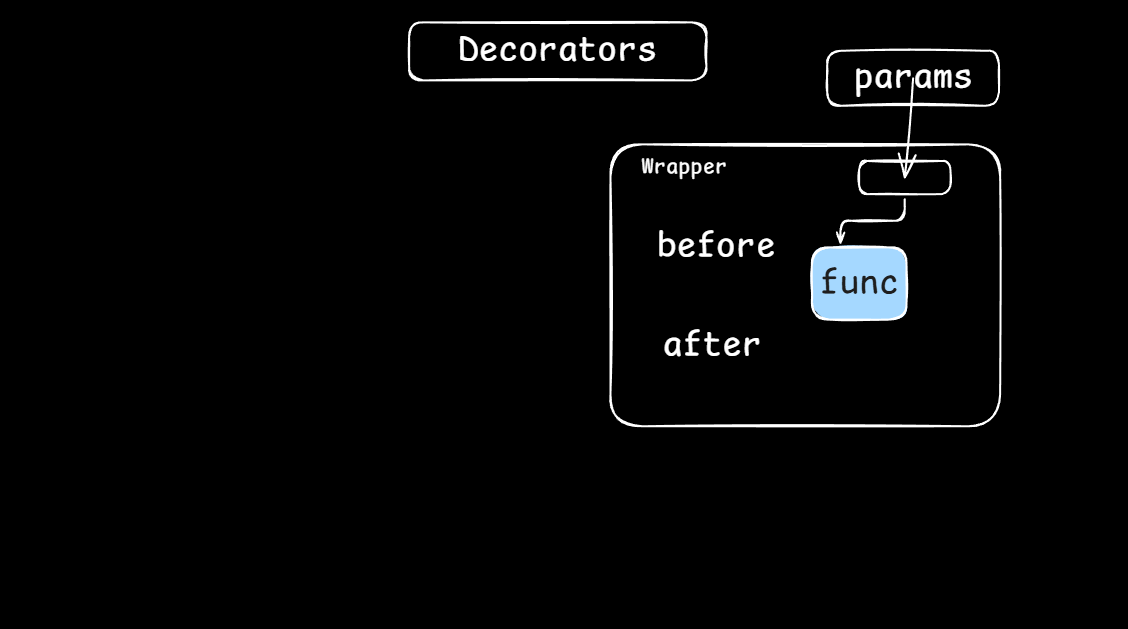

In [15]:
from functools import wraps

def my_Decorator(func):
    @wraps(func)
    def wrapper():
        print('Before Function runs')
        func()
        print('After Function runs')
    return wrapper

@my_Decorator
def greet():
    print('hello! from greet function and decorator class')

def check_decorator():
    print('This is a simple function')

greet()
print(greet.__name__)  #wrapper
print(check_decorator.__name__)  #check_decorator



Before Function runs
hello! from greet function and decorator class
After Function runs
greet
check_decorator


## Building a logger with decorators

In [17]:
from functools import wraps
def log_activity(func):

    @wraps(func)
    def wrapper(*args,**kwargs):
        print(f'Calling : {func.__name__}')
        result=func(*args,**kwargs)
        print(f'Finished ✅: {func.__name__}')
        return result
    return wrapper

@log_activity
def brew_chai(type,milk='no'):
    print(f'Brewing {type} chai and milk status {milk}')

brew_chai('masala chai')

Calling : brew_chai
Brewing masala chai chai and milk status no
Finished ✅: brew_chai


## Building an Authorization decorators